#Image Classification with CNN

In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
!pip install torch torchvision matplotlib -q

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

##Data augmentation and loading dataset

In [4]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True,
    download=True, transform=transform_train)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False,
    download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = trainset.classes


100%|██████████| 170M/170M [00:08<00:00, 20.6MB/s]


##Use Transfer Learning (ResNet18)

In [5]:
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 126MB/s]


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


##Training and evaluation

In [7]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")


Epoch 1, Loss: 1.1091
Epoch 2, Loss: 0.8154
Epoch 3, Loss: 0.7167
Epoch 4, Loss: 0.6718
Epoch 5, Loss: 0.6003


In [8]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 78.69%


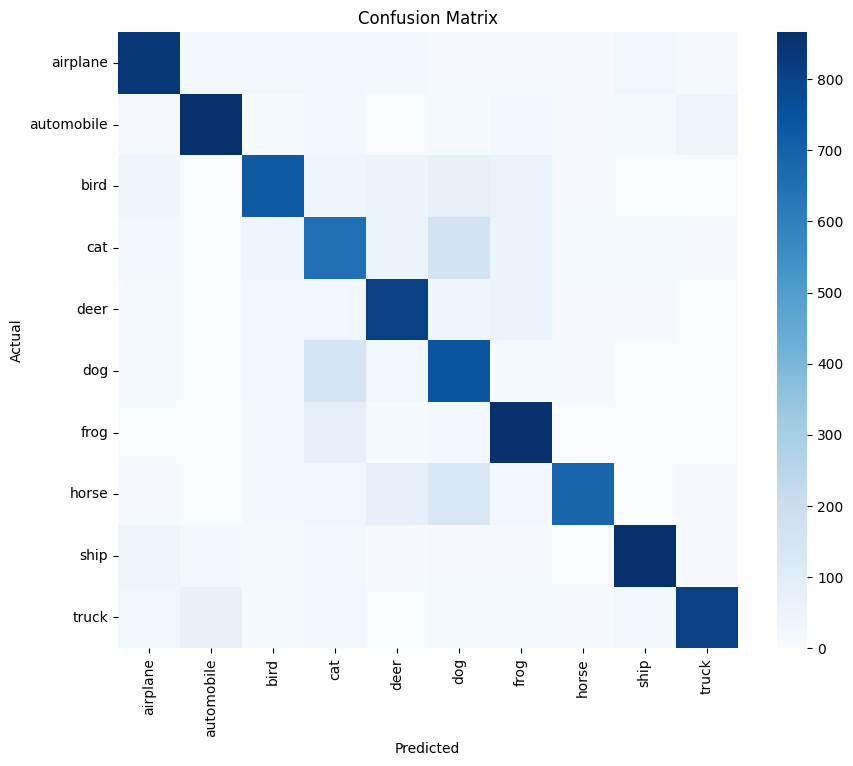

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [10]:
class_correct = [0] * 10
class_total = [0] * 10

for i in range(len(all_labels)):
    label = all_labels[i]
    pred = all_preds[i]

    if label == pred:
        class_correct[label] += 1
    class_total[label] += 1

for i in range(10):
    print(f"{classes[i]} accuracy: {100 * class_correct[i] / class_total[i]:.2f}%")


airplane accuracy: 84.20%
automobile accuracy: 86.30%
bird accuracy: 72.50%
cat accuracy: 65.30%
deer accuracy: 81.30%
dog accuracy: 74.40%
frog accuracy: 86.00%
horse accuracy: 68.90%
ship accuracy: 86.60%
truck accuracy: 81.40%


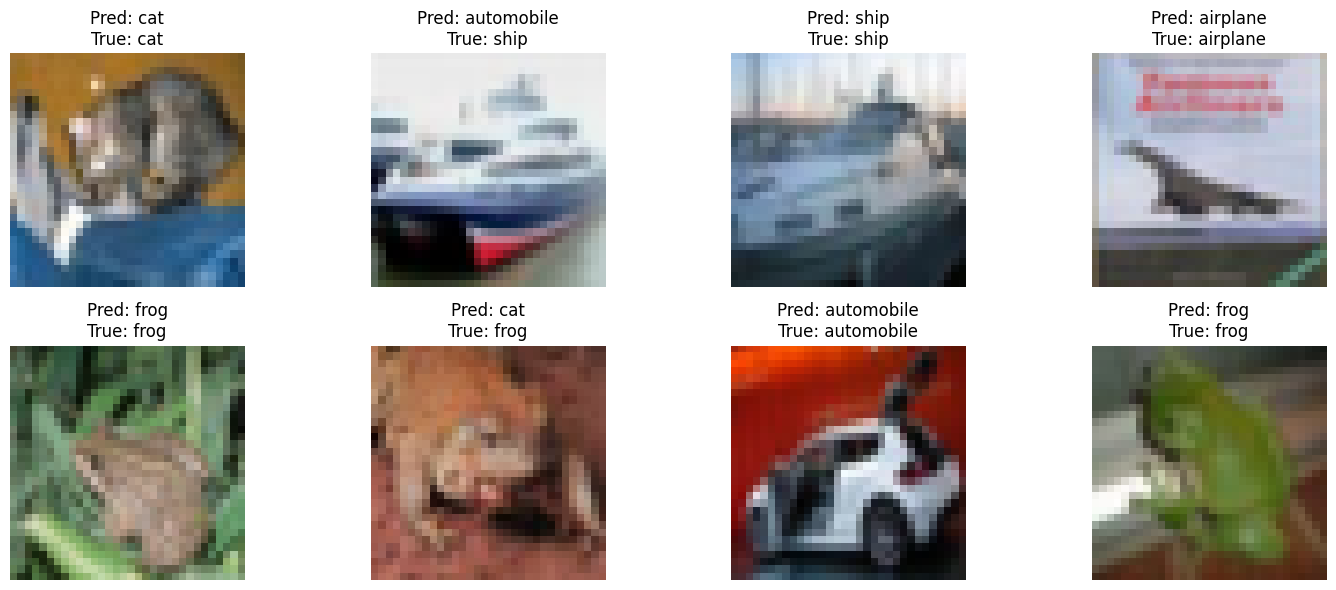

In [11]:
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")

# Get a batch
dataiter = iter(testloader)
images, labels = next(dataiter)

images = images.to(device)
labels = labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(15,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    imshow(images[i].cpu())
    plt.title(f"Pred: {classes[predicted[i]]}\nTrue: {classes[labels[i]]}")

plt.tight_layout()
plt.show()


In [12]:
torch.save(model.state_dict(), "cnn_cifar10.pth")
print("Model saved!")


Model saved!


## Improvising the Accuracy


###Using ResNet34 (Stronger Model)


In [13]:
model = models.resnet34(pretrained=True)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, 10)

# Fine-tune ALL layers
for param in model.parameters():
    param.requires_grad = True

model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 137MB/s]


###Loss, Optimizer & Scheduler

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=5, gamma=0.1
)


###Training and evaluation

In [15]:
epochs = 15

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(trainloader):.4f}")


Epoch 1/15, Loss: 1.1364
Epoch 2/15, Loss: 0.8114
Epoch 3/15, Loss: 0.7313
Epoch 4/15, Loss: 0.7611
Epoch 5/15, Loss: 0.6040
Epoch 6/15, Loss: 0.4884
Epoch 7/15, Loss: 0.4404
Epoch 8/15, Loss: 0.4200
Epoch 9/15, Loss: 0.4016
Epoch 10/15, Loss: 0.3892
Epoch 11/15, Loss: 0.3661
Epoch 12/15, Loss: 0.3591
Epoch 13/15, Loss: 0.3526
Epoch 14/15, Loss: 0.3513
Epoch 15/15, Loss: 0.3537


In [16]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"\nFinal Test Accuracy: {accuracy:.2f}%")



Final Test Accuracy: 85.16%


In [23]:
# Ensure model is in evaluation mode
model.eval()

class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for inputs, labels in testloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        for i in range(labels.size(0)):
            label = labels[i]
            pred = predicted[i]

            if label == pred:
                class_correct[label] += 1
            class_total[label] += 1

print("\nPer-Class Accuracy (ResNet34):\n")

for i in range(10):
    accuracy = 100 * class_correct[i] / class_total[i]
    print(f"{classes[i]:<12} : {accuracy:.2f}%")



Per-Class Accuracy (ResNet34):

airplane     : 88.80%
automobile   : 92.30%
bird         : 83.00%
cat          : 67.80%
deer         : 83.40%
dog          : 78.10%
frog         : 89.60%
horse        : 89.20%
ship         : 91.10%
truck        : 88.30%


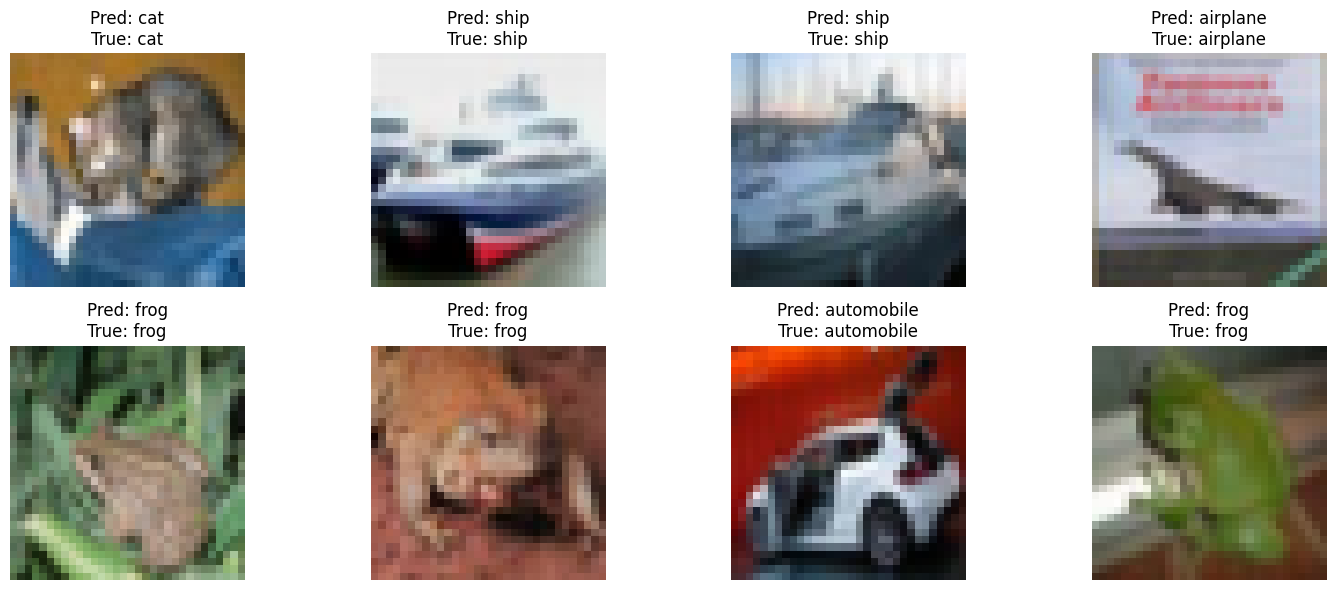

In [17]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")

dataiter = iter(testloader)
images, labels = next(dataiter)

images = images.to(device)
outputs = model(images)
_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(15,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    imshow(images[i].cpu())
    plt.title(f"Pred: {classes[predicted[i]]}\nTrue: {classes[labels[i]]}")

plt.tight_layout()
plt.show()


In [18]:
torch.save(model.state_dict(), "resnet34_cifar10_advanced.pth")
print("Advanced model saved!")


Advanced model saved!
